# Comparación de Técnicas de Tokenización para Series Temporales

## Objetivo

Comparar las 6 técnicas de tokenización identificadas en el Anteproyecto-RITMO sobre el dataset ETTh2.

### Técnicas Comparadas

| Técnica | Paper Original | Tipo |
|---------|---------------|------|
| **HMM (Viterbi)** | Tesis RITMO (2025) | Estados ocultos de Markov |
| **SAX** | Lin et al. (2007) | Discretización gaussiana |
| **LLMTime** | Gruver et al. (2023) | Conversión a texto |
| **PatchTST** | Nie et al. (2023) | Segmentación en patches |
| **Autoformer** | Wu et al. (2021) | Descomposición trend-seasonal |
| **MOMENT** | Goswami et al. (2024) | Masked patches pre-training |

### Dataset

**ETTh2**: Electric Transformer Temperature hourly (17,420 timesteps, 7 variables)

Cache HMM pre-computado disponible con K ∈ {3, 4, 5, 6, 7, 8, 9} estados.

In [1]:
# IMPORTS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pickle
from pathlib import Path
import sys
from scipy import stats

# Añadir path del proyecto
sys.path.append('/home/jaime/TFG/RITMO')

# Imports de técnicas de tokenización
from tecnicas import (
    sax_discretize, visualize_sax,
    text_based_tokenize, visualize_text_based,
    patching_tokenize, visualize_patches,
    decomposition_tokenize, visualize_decomposition,
    foundation_tokenize, visualize_foundation
)

# CONFIGURACIÓN MATPLOTLIB
# Tipografía paper-friendly
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

# Tamaños de fuente (IEEE/Nature standard)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['figure.titlesize'] = 12

# Líneas y grids
plt.rcParams['lines.linewidth'] = 1.0
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['grid.linewidth'] = 0.5
plt.rcParams['grid.alpha'] = 0.3

# Estilo seaborn
sns.set_style('whitegrid')

# Paleta colorblind-friendly (Okabe-Ito recomendada por Nature)
okabe_ito = ['#E69F00', '#56B4E9', '#009E73', '#F0E442',
             '#0072B2', '#D55E00', '#CC79A7', '#000000']
sns.set_palette(okabe_ito)

# Tamaños de figura estándar IEEE Transactions
FIGSIZE_SINGLE = (3.5, 2.625)    # Single column (aspect 4:3)
FIGSIZE_DOUBLE = (7.16, 5.37)    # Double column (aspect 4:3)


# Aplicar semilla inicial para reproducibilidad
def set_seed(seed: int = 42):
    import random
    import numpy as _np
    random.seed(seed)
    _np.random.seed(seed)
    try:
        import torch as _torch
        _torch.manual_seed(seed)
        _torch.cuda.manual_seed_all(seed)
    except Exception:
        pass

set_seed(42)

print("[OK] Imports completados")
print(f"Versiones: NumPy {np.__version__}, Pandas {pd.__version__}, Matplotlib {plt.matplotlib.__version__}")
print("Configuración aplicada")
print("  - Paleta: Okabe-Ito (colorblind-friendly)")
print(f"  - Tamaños: Single={FIGSIZE_SINGLE}, Double={FIGSIZE_DOUBLE}")
print("  - Guardado: PDF (vectorial) + PNG (raster)")

[OK] Imports completados
Versiones: NumPy 2.2.6, Pandas 2.3.3, Matplotlib 3.10.8
Configuración aplicada
  - Paleta: Okabe-Ito (colorblind-friendly)
  - Tamaños: Single=(3.5, 2.625), Double=(7.16, 5.37)
  - Guardado: PDF (vectorial) + PNG (raster)


In [2]:
# Cargar cache HMM del pipeline RITMO
import torch
BASE_DIR = Path('/home/jaime/TFG/RITMO')
DATASET_DIR = BASE_DIR / 'dataset'
CACHE_DIR = BASE_DIR / 'cache'

# Cargar parámetros HMM entrenados
K_SELECTED = 5
cache_path = CACHE_DIR / f'hmm_etth2_K{K_SELECTED}.pth'
hmm_cache = torch.load(cache_path, weights_only=False)

print("[CACHE HMM]")
print(f"  Archivo: {cache_path}")
print(f"  K={K_SELECTED} estados")
print(f"  Convergencia: {hmm_cache['converged']} (iter {hmm_cache['n_iter']})")
print(f"  Log-likelihood: {hmm_cache['log_likelihood']:.2f}")

[CACHE HMM]
  Archivo: /home/jaime/TFG/RITMO/cache/hmm_etth2_K5.pth
  K=5 estados
  Convergencia: True (iter 231)
  Log-likelihood: -6804.52


In [3]:
# Cargar y normalizar dataset ETTh2 con RevIN
df_etth2 = pd.read_csv(DATASET_DIR / 'ETT-small' / 'ETTh2.csv')

print("[DATASET RAW]")
print(f"  ETTh2: {df_etth2.shape[0]} timesteps, {df_etth2.shape[1]-1} variables")
print(f"  Columnas: {df_etth2.columns.tolist()}")

# Extraer columna OT y aplicar train split (70%)
data_raw = df_etth2['OT'].values
n_train = int(len(data_raw) * 0.7)
train_raw = data_raw[:n_train]

# Normalizar con RevIN
train_mean = train_raw.mean()
train_std = train_raw.std()
train_norm = (train_raw - train_mean) / train_std

print(f"\n[NORMALIZACIÓN REVIN]")
print(f"  Train size: {len(train_raw)} timesteps")
print(f"  Media original: {train_mean:.4f}")
print(f"  Std original: {train_std:.4f}")
print(f"  Media normalizada: {train_norm.mean():.6f}")
print(f"  Std normalizada: {train_norm.std():.6f}")

[DATASET RAW]
  ETTh2: 17420 timesteps, 7 variables
  Columnas: ['date', 'HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT']

[NORMALIZACIÓN REVIN]
  Train size: 12194 timesteps
  Media original: 28.8172
  Std original: 11.4034
  Media normalizada: 0.000000
  Std normalizada: 1.000000


In [4]:
# Ejecutar Viterbi para obtener secuencia de estados
from hmm.viterbi import viterbi_decode

# Convertir parámetros de torch a numpy
params_np = {
    'A': hmm_cache['A'].numpy(),
    'pi': hmm_cache['pi'].numpy(),
    'mu': hmm_cache['mu'].numpy(),
    'sigma': hmm_cache['sigma'].numpy()
}

# Decodificar con Viterbi (retorna states y log_prob)
states, log_prob = viterbi_decode(
    train_norm,
    params_np['A'],
    params_np['pi'],
    params_np['mu'],
    params_np['sigma']
)

# Calcular métricas
n_segments = np.sum(np.diff(np.concatenate([[states[0]], states])) != 0)
compression_ratio = len(train_norm) / n_segments if n_segments > 0 else len(train_norm)

# Calcular entropía de estados
state_counts = np.bincount(states, minlength=K_SELECTED)
state_probs = state_counts / len(states)
state_entropy = -np.sum(state_probs[state_probs > 0] * np.log(state_probs[state_probs > 0]))

# Construir estructura compatible con código existente
hmm_etth2 = {
    'K': K_SELECTED,
    'hmm_converged': hmm_cache['converged'],
    'hmm_n_iter': hmm_cache['n_iter'],
    'log_likelihood': float(hmm_cache['log_likelihood']),
    'compression_ratio': compression_ratio,
    'n_segments': n_segments,
    'state_entropy': state_entropy,
    'data_norm': train_norm,
    'states': states,
    'params': params_np
}

print(f"\n[TOKENIZACIÓN VITERBI]")
print(f"  Estados únicos: {len(np.unique(states))}/{K_SELECTED}")
print(f"  Segmentos (cambios de estado): {n_segments}")
print(f"  Compression Ratio: {compression_ratio:.2f}")
print(f"  Entropía estados: {state_entropy:.3f} (max={np.log(K_SELECTED):.3f})")
print(f"  Viterbi log-prob: {log_prob:.2f}")


[TOKENIZACIÓN VITERBI]
  Estados únicos: 5/5
  Segmentos (cambios de estado): 851
  Compression Ratio: 14.33
  Entropía estados: 1.597 (max=1.609)
  Viterbi log-prob: -4929.45


In [5]:
# Extraer datos para visualización
etth2_data_norm = hmm_etth2['data_norm']
etth2_states = hmm_etth2['states']
etth2_params = hmm_etth2['params']

print("[DATOS EXTRAÍDOS]")
print(f"  Serie normalizada: {len(etth2_data_norm)} timesteps")
print(f"  Secuencia Viterbi: {len(etth2_states)} estados")
print(f"  Estados únicos usados: {len(np.unique(etth2_states))}/{K_SELECTED}")
print(f"\n  Parámetros HMM:")
print(f"    mu (medias): {etth2_params['mu']}")
print(f"    sigma (std): {etth2_params['sigma']}")

[DATOS EXTRAÍDOS]
  Serie normalizada: 12194 timesteps
  Secuencia Viterbi: 12194 estados
  Estados únicos usados: 5/5

  Parámetros HMM:
    mu (medias): [-0.6209477   0.62043524 -0.0715721   1.6143241  -1.2359613 ]
    sigma (std): [0.17692941 0.2690333  0.19745292 0.47711003 0.3213895 ]


In [6]:
# Seleccionar ventana de visualización (primeros 1500 timesteps)
N_TIMESTEPS = 1500

etth2_series = etth2_data_norm[:N_TIMESTEPS]
etth2_states_vis = etth2_states[:N_TIMESTEPS]

print(f"[VENTANA DE VISUALIZACIÓN]")
print(f"  Timesteps seleccionados: {N_TIMESTEPS}")
print(f"  Porcentaje de serie completa: {N_TIMESTEPS/len(etth2_data_norm)*100:.1f}%")

[VENTANA DE VISUALIZACIÓN]
  Timesteps seleccionados: 1500
  Porcentaje de serie completa: 12.3%


In [7]:
print("[TOKENIZANDO ETTH2]")

# SAX - Discretización con alfabeto de 8 símbolos
etth2_sax = sax_discretize(etth2_series, alphabet_size=8)
print(f"  SAX: {etth2_sax['vocabulary_size']} símbolos, {etth2_sax['num_tokens']} tokens")

# LLMTime - Conversión a texto base-10 con 2 decimales
etth2_text = text_based_tokenize(etth2_series, base=10, precision=2)
print(f"  LLMTime: {etth2_text['num_tokens']} caracteres, vocabulario={etth2_text['vocabulary_size']}")

# PatchTST - Segmentación en patches de 16 timesteps sin solapamiento
etth2_patch_array = patching_tokenize(etth2_series, patch_len=16, stride=16)
etth2_patch = visualize_patches(etth2_series, etth2_patch_array, 16, 16)
print(f"  PatchTST: {etth2_patch['num_patches']} patches, CR={etth2_patch['compression_ratio']:.2f}")

# Autoformer - Descomposición trend-seasonal con ventana móvil=25
etth2_decomp = decomposition_tokenize(etth2_series, kernel_size=25)
print(f"  Autoformer: {etth2_decomp['num_tokens']} componentes (trend + seasonal)")

# MOMENT - Masked patches con 30% enmascarado
etth2_foundation = foundation_tokenize(etth2_series, patch_len=16, stride=16, mask_ratio=0.3, random_seed=42)
print(f"  MOMENT: {etth2_foundation['num_patches']} patches, {etth2_foundation['num_masked']} masked ({etth2_foundation['mask_ratio_actual']*100:.1f}%)")

print("\n[OK] Todas las técnicas aplicadas")

[TOKENIZANDO ETTH2]
  SAX: 8 símbolos, 1500 tokens
  LLMTime: 15055 caracteres, vocabulario=13
  PatchTST: 93 patches, CR=16.13
  Autoformer: 2 componentes (trend + seasonal)
  MOMENT: 93 patches, 28 masked (30.1%)

[OK] Todas las técnicas aplicadas


In [8]:
def create_comparison_table(dataset_name, series_len, hmm_result, hmm_states_vis, sax, text, patch, decomp, foundation):
    """Crear tabla comparativa de métricas de tokenización."""
    # HMM: calcular número de segmentos en ventana visible
    num_segments_vis = np.sum(np.diff(np.concatenate([[hmm_states_vis[0]], hmm_states_vis])) != 0)
    cr_vis = series_len / num_segments_vis if num_segments_vis > 0 else series_len

    data = [
        {
            'Técnica': 'HMM (Viterbi)',
            'Segmentos': num_segments_vis,
            'Compression Ratio': cr_vis,
            'Vocabulary Size': hmm_result['K'],
            'Tipo': 'Probabilístico',
            'Paper': 'Tesis RITMO (2025)'
        },
        {
            'Técnica': 'SAX',
            'Segmentos': sax['num_tokens'],
            'Compression Ratio': sax['compression_ratio'],
            'Vocabulary Size': sax['vocabulary_size'],
            'Tipo': 'Discreto',
            'Paper': 'Lin et al. (2007)'
        },
        {
            'Técnica': 'LLMTime',
            'Segmentos': text['num_tokens'],
            'Compression Ratio': text['compression_ratio'],
            'Vocabulary Size': text['vocabulary_size'],
            'Tipo': 'Textual',
            'Paper': 'Gruver et al. (2023)'
        },
        {
            'Técnica': 'PatchTST',
            'Segmentos': patch['num_patches'],
            'Compression Ratio': patch['compression_ratio'],
            'Vocabulary Size': 'Continuo',
            'Tipo': 'Segmentación',
            'Paper': 'Nie et al. (2023)'
        },
        {
            'Técnica': 'Autoformer',
            'Segmentos': decomp['num_tokens'],
            'Compression Ratio': decomp['compression_ratio'],
            'Vocabulary Size': '2 componentes',
            'Tipo': 'Descomposición',
            'Paper': 'Wu et al. (2021)'
        },
        {
            'Técnica': 'MOMENT',
            'Segmentos': foundation['num_patches'],
            'Compression Ratio': foundation['compression_ratio'],
            'Vocabulary Size': f"{foundation['num_masked']} masked",
            'Tipo': 'Pre-training',
            'Paper': 'Goswami et al. (2024)'
        }
    ]

    df = pd.DataFrame(data)
    df['Dataset'] = dataset_name
    df['Serie Length'] = series_len
    return df

# Crear tabla
table_etth2 = create_comparison_table('ETTh2', len(etth2_series), hmm_etth2, etth2_states_vis,
                                       etth2_sax, etth2_text, etth2_patch, etth2_decomp, etth2_foundation)

print("-"*140)
print("TABLA COMPARATIVA DE TÉCNICAS DE TOKENIZACIÓN - ETTH2")
print("-"*140)
print(table_etth2.to_string(index=False))
print("-"*140)

--------------------------------------------------------------------------------------------------------------------------------------------
TABLA COMPARATIVA DE TÉCNICAS DE TOKENIZACIÓN - ETTH2
--------------------------------------------------------------------------------------------------------------------------------------------
      Técnica  Segmentos  Compression Ratio Vocabulary Size           Tipo                 Paper Dataset  Serie Length
HMM (Viterbi)         66          22.727273               5 Probabilístico    Tesis RITMO (2025)   ETTh2          1500
          SAX       1500           1.000000               8       Discreto     Lin et al. (2007)   ETTh2          1500
      LLMTime      15055           0.099635              13        Textual  Gruver et al. (2023)   ETTh2          1500
     PatchTST         93          16.129032        Continuo   Segmentación     Nie et al. (2023)   ETTh2          1500
   Autoformer          2         750.000000   2 componentes Descompos

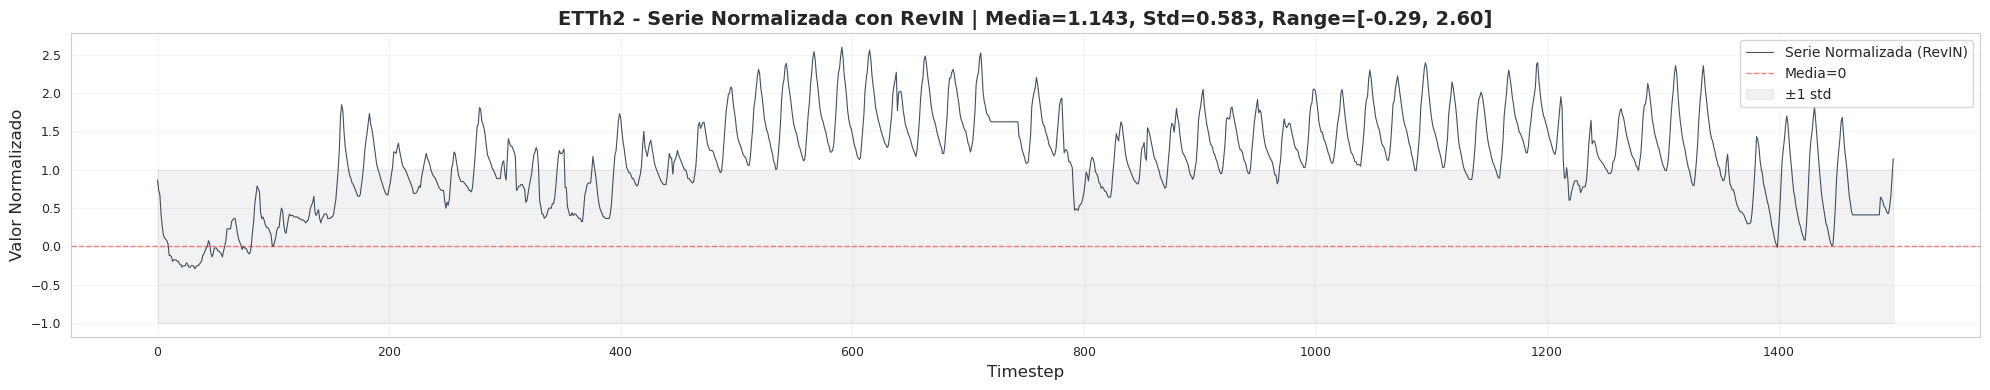

[ESTADÍSTICAS SERIE NORMALIZADA]
  Media: 1.142809 (debe estar cerca de 0)
  Desviación estándar: 0.582622 (debe estar cerca de 1)
  Min: -0.293, Max: 2.598
  Rango: 2.890


In [9]:
# Visualizar serie normalizada con RevIN
fig, ax = plt.subplots(figsize=(20, 4))

ax.plot(etth2_series, linewidth=0.8, color='#2C3E50', alpha=0.9, label='Serie Normalizada (RevIN)')
ax.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Media=0')
ax.fill_between(range(len(etth2_series)), -1, 1, alpha=0.1, color='gray', label='±1 std')

# Calcular estadísticas
mean_val = etth2_series.mean()
std_val = etth2_series.std()
min_val = etth2_series.min()
max_val = etth2_series.max()

ax.set_title(f'ETTh2 - Serie Normalizada con RevIN | Media={mean_val:.3f}, Std={std_val:.3f}, Range=[{min_val:.2f}, {max_val:.2f}]',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Timestep', fontsize=12)
ax.set_ylabel('Valor Normalizado', fontsize=12)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"[ESTADÍSTICAS SERIE NORMALIZADA]")
print(f"  Media: {mean_val:.6f} (debe estar cerca de 0)")
print(f"  Desviación estándar: {std_val:.6f} (debe estar cerca de 1)")
print(f"  Min: {min_val:.3f}, Max: {max_val:.3f}")
print(f"  Rango: {max_val - min_val:.3f}")

## Técnica 1: HMM - Estados Ocultos de Markov

**Descripción:**
- Entrena HMM con K=5 estados usando algoritmo Baum-Welch (EM)
- Cada estado k tiene distribución gaussiana N(μ_k, σ²_k)
- Algoritmo Viterbi encuentra secuencia óptima Q* = argmax P(Q|O,λ)
- Estados capturan regímenes temporales de la serie

**Interpretación:**
- Colores indican estado activo en cada timestep
- Líneas horizontales punteadas: medias μ_k de cada estado
- Cambios de color: transiciones entre regímenes
- Matriz A: probabilidades de transición P(j|i)

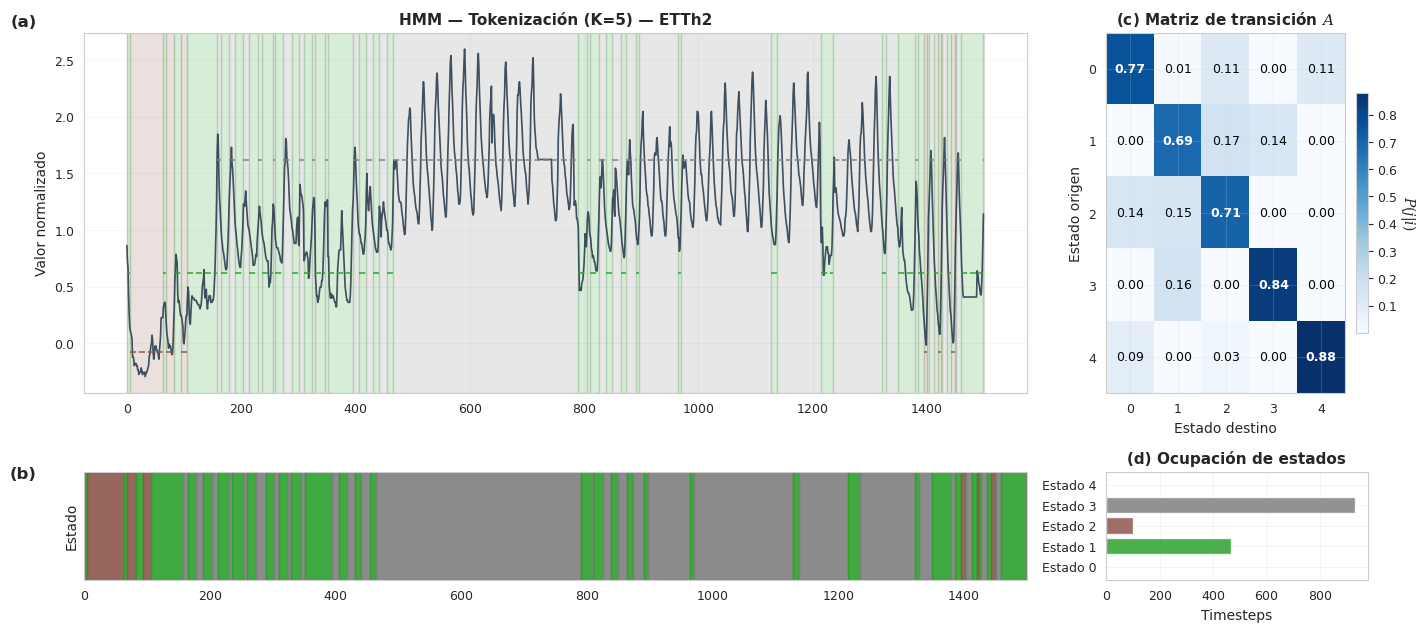

[ESTADÍSTICAS HMM]
  Número de estados (K): 5
  Estados únicos usados: 3
  Compression Ratio: 14.33
  Número de segmentos: 851
  Duración promedio segmento: 22.39 timesteps
  Entropía de estados: 1.597 (max=1.609)

  Parámetros por estado:
    Estado 0: μ=-0.621, σ=0.177, freq=0.0% (0 timesteps)
    Estado 1: μ=0.620, σ=0.269, freq=31.2% (468 timesteps)
    Estado 2: μ=-0.072, σ=0.197, freq=6.7% (101 timesteps)
    Estado 3: μ=1.614, σ=0.477, freq=62.1% (931 timesteps)
    Estado 4: μ=-1.236, σ=0.321, freq=0.0% (0 timesteps)


In [10]:
fig = plt.figure(figsize=(FIGSIZE_DOUBLE[0]*2, FIGSIZE_DOUBLE[1]*1.6))
gs = fig.add_gridspec(3, 4, height_ratios=[2, 0.6, 1])
ax_series = fig.add_subplot(gs[0, :3])
ax_statebar = fig.add_subplot(gs[1, :3])
ax_trans = fig.add_subplot(gs[0, 3])
ax_occup = fig.add_subplot(gs[1, 3])

# Serie (panel principal)
ax_series.plot(etth2_series, linewidth=1.2, color='#2C3E50', alpha=0.9, label='Serie')
ax_series.set_title(f'HMM — Tokenización (K={K_SELECTED}) — ETTh2', fontsize=11, fontweight='bold')
ax_series.set_ylabel('Valor normalizado')
ax_series.grid(True, alpha=0.25)
ax_series.text(-0.05, 1.05, '(a)', transform=ax_series.transAxes,
               fontsize=12, fontweight='bold', va='top', ha='right')

# Contiguous segments (inicio, fin, estado)
segments = []
if len(etth2_states_vis) > 0:
    start = 0
    curr = int(etth2_states_vis[0])
    for i, s in enumerate(etth2_states_vis):
        s = int(s)
        if s != curr:
            segments.append((start, i, curr))
            start = i; curr = s
    segments.append((start, len(etth2_states_vis), curr))
else:
    segments = []

# Colores accesibles y consistentes
colors = plt.get_cmap('tab10')(np.linspace(0, 1, max(K_SELECTED, 1)))

# Dibujar spans por segmento y línea de media por estado (si está disponible)
for (s, e, state) in segments:
    c = colors[state % len(colors)]
    ax_series.axvspan(s, e, color=c, alpha=0.18)
    mu_k = etth2_params.get('mu', [np.nan]*K_SELECTED)[state]
    ax_series.hlines(mu_k, s, e, colors=[c], linestyles='--', linewidth=1.2, alpha=0.9)

# Barra compacta de estados
for (s, e, state) in segments:
    c = colors[state % len(colors)]
    ax_statebar.axvspan(s, e, color=c, alpha=0.9)
ax_statebar.set_yticks([])
ax_statebar.set_ylabel('Estado')
ax_statebar.set_xlim(0, len(etth2_series))
ax_statebar.grid(False)
ax_statebar.text(-0.05, 1.05, '(b)', transform=ax_statebar.transAxes,
                 fontsize=12, fontweight='bold', va='top', ha='right')

# Matriz de transición (derecha superior) — acceso seguro
A = etth2_params.get('A', None)
if A is None:
    A = etth2_params.get('trans_mat', None)
if A is None:
    A = hmm_etth2.get('A', None)

if A is not None:
    im = ax_trans.imshow(np.array(A), aspect='auto', cmap='Blues')
    ax_trans.set_title('(c) Matriz de transición $A$', fontsize=11, fontweight='bold')
    ax_trans.set_xlabel('Estado destino')
    ax_trans.set_ylabel('Estado origen')
    cbar = plt.colorbar(im, ax=ax_trans, fraction=0.046, pad=0.04)
    cbar.set_label('$P(j|i)$', rotation=270, labelpad=15)

    # Anotar valores en cada celda
    for i in range(K_SELECTED):
        for j in range(K_SELECTED):
            text_color = 'white' if A[i,j] > 0.5 else 'black'
            ax_trans.text(j, i, f'{A[i,j]:.2f}', ha='center', va='center',
                        color=text_color, fontsize=9, fontweight='bold' if i==j else 'normal')
else:
    ax_trans.text(0.5, 0.5, 'A no disponible', ha='center', va='center', fontsize=10)
    ax_trans.text(-0.05, 1.05, '(c)', transform=ax_trans.transAxes,
                  fontsize=12, fontweight='bold', va='top', ha='right')

# Barra de ocupación (derecha inferior)
state_counts = [(etth2_states_vis==k).sum() for k in range(K_SELECTED)]
ax_occup.barh(range(K_SELECTED), state_counts, color=colors[:K_SELECTED], alpha=0.85)
ax_occup.set_yticks(range(K_SELECTED))
ax_occup.set_yticklabels([f'Estado {k}' for k in range(K_SELECTED)])
ax_occup.set_xlabel('Timesteps')
ax_occup.set_title('(d) Ocupación de estados', fontsize=11, fontweight='bold')

# Ajuste y mostrar
plt.tight_layout()

# Guardar figura
fig.savefig('figures/hmm_tokenizacion_ETTh2.png', dpi=300, bbox_inches='tight')
plt.show()

print('[ESTADÍSTICAS HMM]')
print(f'  Número de estados (K): {K_SELECTED}')
print(f'  Estados únicos usados: {len(np.unique(etth2_states_vis))}')
print(f"  Compression Ratio: {hmm_etth2.get('compression_ratio', np.nan):.2f}")
print(f"  Número de segmentos: {hmm_etth2.get('n_segments', np.sum(np.diff(np.concatenate([[etth2_states_vis[0]], etth2_states_vis])) != 0))}")
print(f"  Duración promedio segmento: {hmm_etth2.get('avg_segment_duration', np.mean([e-s for s,e,_ in segments]) if segments else np.nan):.2f} timesteps")
print(f"  Entropía de estados: {hmm_etth2.get('state_entropy', np.nan):.3f} (max={np.log(K_SELECTED):.3f})")

print('\n  Parámetros por estado:')
for k in range(K_SELECTED):
    count = int((etth2_states_vis == k).sum())
    pct = (count / len(etth2_states_vis) * 100) if len(etth2_states_vis) > 0 else 0.0
    mu_k = etth2_params.get('mu', [np.nan]*K_SELECTED)[k]
    sigma_k = etth2_params.get('sigma', [np.nan]*K_SELECTED)[k]
    print(f'    Estado {k}: μ={mu_k:.3f}, σ={sigma_k:.3f}, freq={pct:.1f}% ({count} timesteps)')

## Técnica 2: SAX - Symbolic Aggregate approXimation

**Descripción:**
- Normaliza serie con z-score: (x - μ) / σ
- Divide espacio en N regiones equiprobables bajo N(0,1)
- Asigna símbolo alfabético a cada timestep según región
- Vocabulario de 8 símbolos: {a, b, c, d, e, f, g, h}

**Interpretación:**
- Líneas rojas horizontales: breakpoints gaussianos
- Puntos coloreados: símbolos discretos asignados
- Reduce serie continua a secuencia de caracteres

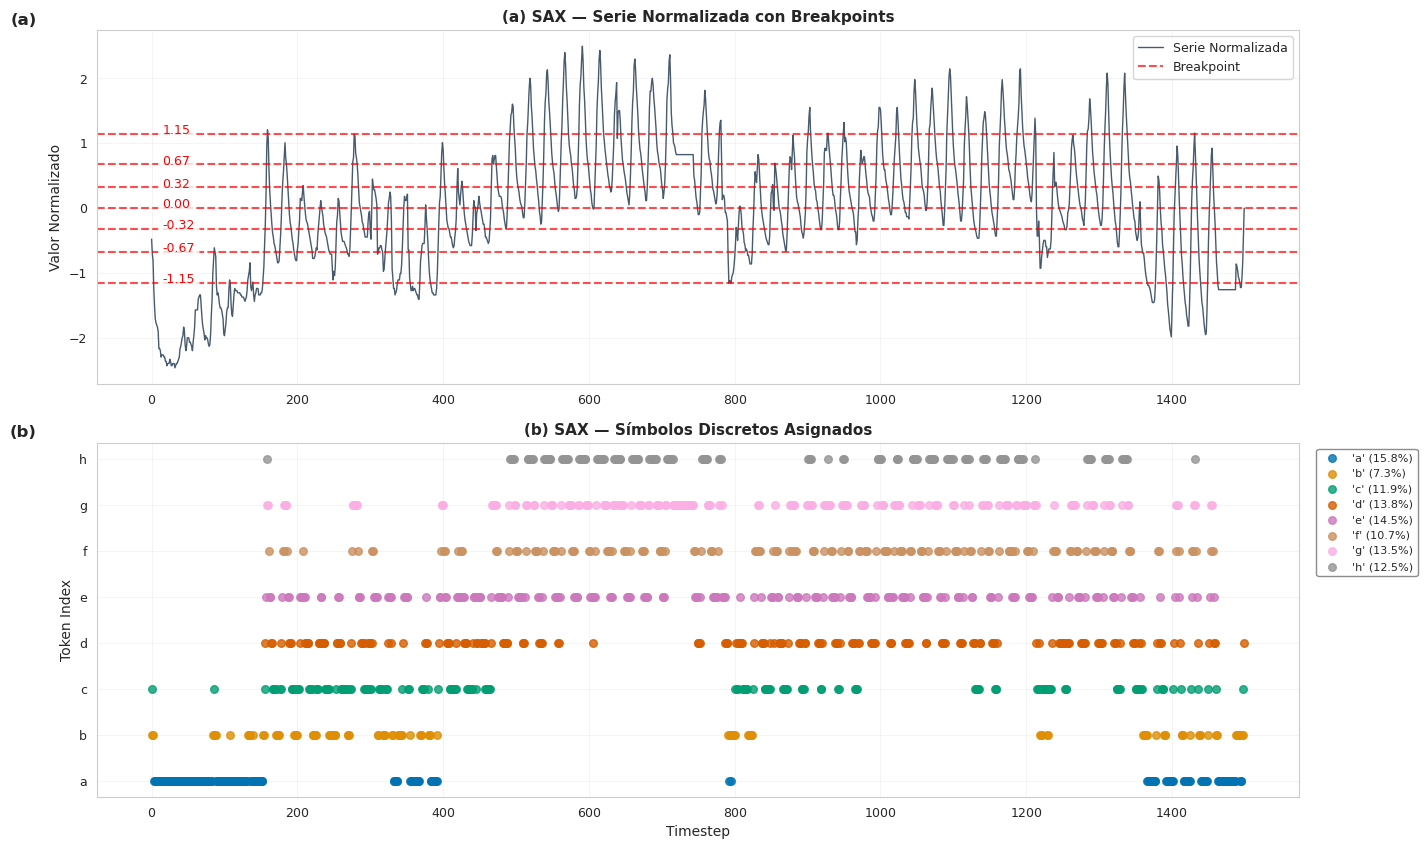

[ESTADÍSTICAS SAX]
  Vocabulary Size: 8
  Símbolos únicos usados: 8
  Num Tokens: 1500
  Compression Ratio: 1.0000 (sin compresión)


In [11]:
sax_viz = visualize_sax(etth2_series, etth2_sax['symbols'], etth2_sax['tokens'], etth2_sax['breakpoints'])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(FIGSIZE_DOUBLE[0]*2, FIGSIZE_DOUBLE[1]*1.6))

# Panel (a): Serie normalizada con breakpoints
ax1.plot(sax_viz['normalized'], linewidth=1, color='#34495E', alpha=0.9, label='Serie Normalizada')
for i, bp in enumerate(etth2_sax['breakpoints']):
    ax1.axhline(bp, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Breakpoint' if i == 0 else '')
    ax1.text(len(etth2_series)*0.01, bp, f'{bp:.2f}', fontsize=9, color='red', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax1.set_title('(a) SAX — Serie Normalizada con Breakpoints', fontsize=11, fontweight='bold')
ax1.set_ylabel('Valor Normalizado', fontsize=10)
ax1.legend(fontsize=9, loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.text(-0.05, 1.05, '(a)', transform=ax1.transAxes,
         fontsize=12, fontweight='bold', va='top', ha='right')

# Panel (b): Símbolos discretos asignados
colors_sax = sns.color_palette('colorblind', n_colors=etth2_sax['vocabulary_size'])
for sym_idx in range(etth2_sax['vocabulary_size']):
    mask = etth2_sax['tokens'] == sym_idx
    if mask.any():
        count = mask.sum()
        pct = count / len(etth2_series) * 100
        ax2.scatter(np.where(mask)[0], etth2_sax['tokens'][mask], color=colors_sax[sym_idx], s=30, alpha=0.8, label=f"'{etth2_sax['alphabet'][sym_idx]}' ({pct:.1f}%)")

ax2.set_title('(b) SAX — Símbolos Discretos Asignados', fontsize=11, fontweight='bold')
ax2.set_ylabel('Token Index', fontsize=10)
ax2.set_xlabel('Timestep', fontsize=10)
ax2.set_yticks(range(etth2_sax['vocabulary_size']))
ax2.set_yticklabels([etth2_sax['alphabet'][i] for i in range(etth2_sax['vocabulary_size'])])
ax2.legend(loc='upper left', bbox_to_anchor=(1.01, 1), ncol=1, fontsize=8, framealpha=0.9, edgecolor='gray')
ax2.grid(True, alpha=0.3)
ax2.text(-0.05, 1.05, '(b)', transform=ax2.transAxes,
         fontsize=12, fontweight='bold', va='top', ha='right')

plt.tight_layout()

# Guardar figura
fig.savefig('figures/sax_discretizacion_ETTh2.png', dpi=300, bbox_inches='tight')
plt.show()

print('[ESTADÍSTICAS SAX]')
print(f"  Vocabulary Size: {etth2_sax['vocabulary_size']}")
print(f"  Símbolos únicos usados: {len(np.unique(etth2_sax['symbols']))}")
print(f"  Num Tokens: {etth2_sax['num_tokens']}")
print(f"  Compression Ratio: {etth2_sax['compression_ratio']:.4f} (sin compresión)")

## Técnica 3: LLMTime - Text-based Tokenization

**Descripción:**
- Convierte cada valor numérico a representación textual
- Base 10 decimal con 2 dígitos de precisión
- Separa dígitos con espacios: 23.45 → " 2 3 . 4 5"
- LLMs procesan serie como secuencia de caracteres

**Interpretación:**
- Longitud de token varía según magnitud del valor
- Valores grandes → tokens más largos
- Compression ratio < 1 (expansión, no compresión)

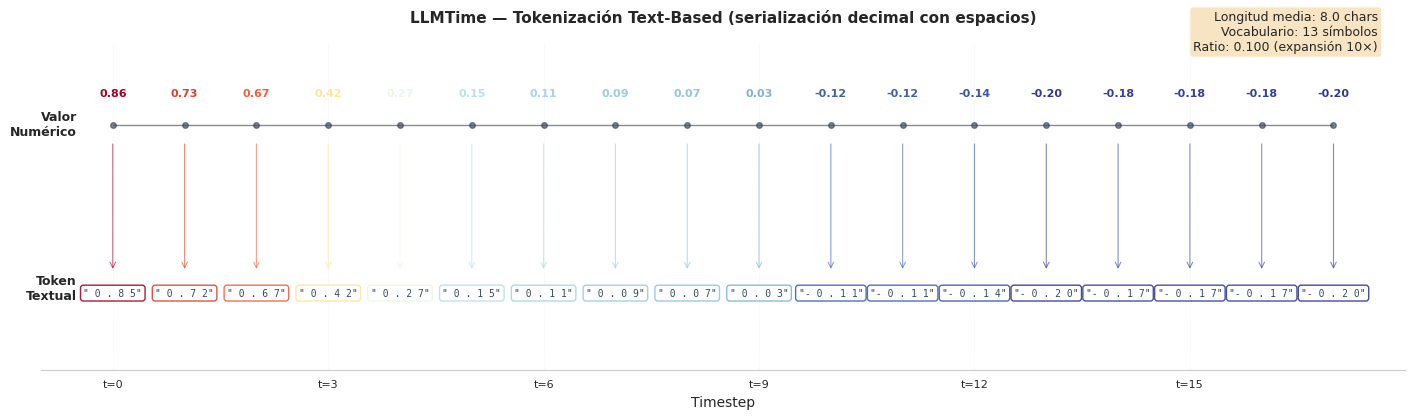

[ESTADÍSTICAS LLMTIME]
  Total caracteres: 12057
  Longitud media token: 8.04 caracteres
  Compression Ratio: 0.099635 (expansión, no compresión)
  Tamaño vocabulario: 13 (dígitos, signo, punto, separador)


In [12]:
text_viz = visualize_text_based(etth2_series, etth2_text['tokens_per_value'])

# Crear visualización compacta: Timeline de transformación valor → token
N_EXAMPLES = 18  # Número de ejemplos a mostrar
example_values = etth2_series[:N_EXAMPLES]
example_tokens = etth2_text.get('tokens_per_value', [])[:N_EXAMPLES]

fig = plt.figure(figsize=(FIGSIZE_DOUBLE[0]*2, FIGSIZE_DOUBLE[1]*0.8))
ax = fig.add_subplot(111)

# Remover spines para diseño limpio
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(True)

# Dibujar mini line plot de la serie en la parte superior
y_series = 0.75
x_positions = np.arange(N_EXAMPLES)
ax.plot(x_positions, [y_series]*N_EXAMPLES, 'o-', color='#2C3E50', markersize=4, linewidth=1, alpha=0.6)

# Normalizar valores para colorear por magnitud
norm_vals = (example_values - example_values.min()) / (example_values.max() - example_values.min() + 1e-8)
colors_map = plt.cm.RdYlBu_r(norm_vals)

# Dibujar cada valor con su token correspondiente
y_token = 0.25
for i, (val, token) in enumerate(zip(example_values, example_tokens)):
    # Valor numérico arriba
    ax.text(i, y_series + 0.08, f'{val:.2f}', ha='center', va='bottom',
            fontsize=8, color=colors_map[i], fontweight='bold')

    # Flecha de conexión
    ax.annotate('', xy=(i, y_token + 0.05), xytext=(i, y_series - 0.05),
                arrowprops=dict(arrowstyle='->', color=colors_map[i], lw=0.8, alpha=0.6))

    # Token textual abajo
    ax.text(i, y_token, f'"{token}"', ha='center', va='top',
            fontsize=7, family='monospace', color='#34495E',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=colors_map[i], alpha=0.9))

# Labels
ax.text(-0.5, y_series, 'Valor\nNumérico', ha='right', va='center', fontsize=9, fontweight='bold')
ax.text(-0.5, y_token, 'Token\nTextual', ha='right', va='center', fontsize=9, fontweight='bold')

# Métricas en box
avg_len = text_viz.get('avg_token_length', 0)
vocab_size = etth2_text.get('vocabulary_size', 0)
comp_ratio = etth2_text.get('compression_ratio', 0)
metrics_text = (f'Longitud media: {avg_len:.1f} chars\n'
                f'Vocabulario: {vocab_size} símbolos\n'
                f'Ratio: {comp_ratio:.3f} (expansión 10×)')
ax.text(0.98, 1.1, metrics_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Título y configuración
ax.set_title('LLMTime — Tokenización Text-Based (serialización decimal con espacios)',
             fontsize=11, fontweight='bold', pad=15)
ax.set_xlim(-1, N_EXAMPLES)
ax.set_ylim(0, 1)
ax.set_xticks(x_positions[::3])
ax.set_xticklabels([f't={i}' for i in x_positions[::3]], fontsize=8)
ax.set_yticks([])
ax.set_xlabel('Timestep', fontsize=10)
ax.grid(True, axis='x', alpha=0.2, linestyle='--')

plt.tight_layout()

# Guardar figura
fig.savefig('figures/llmtime_text_based_ETTh2.png', dpi=300, bbox_inches='tight')
plt.show()

print('[ESTADÍSTICAS LLMTIME]')
print(f"  Total caracteres: {text_viz.get('total_characters', 0)}")
print(f"  Longitud media token: {text_viz.get('avg_token_length', 0):.2f} caracteres")
print(f"  Compression Ratio: {etth2_text.get('compression_ratio', 0):.6f} (expansión, no compresión)")
print(f"  Tamaño vocabulario: {etth2_text.get('vocabulary_size', 0)} (dígitos, signo, punto, separador)")

## Técnica 4: PatchTST - Patch-based Tokenization

**Descripción:**
- Divide serie en patches de longitud fija (16 timesteps)
- Sin solapamiento (stride=16)
- Cada patch es un token multidimensional ∈ R^16
- Reduce complejidad de O(L²) a O((L/P)²) en Transformers

**Interpretación:**
- Líneas rojas verticales: boundaries entre patches
- Heatmap: cada columna es un patch, colores = valores
- Varianza por patch: indica variabilidad local

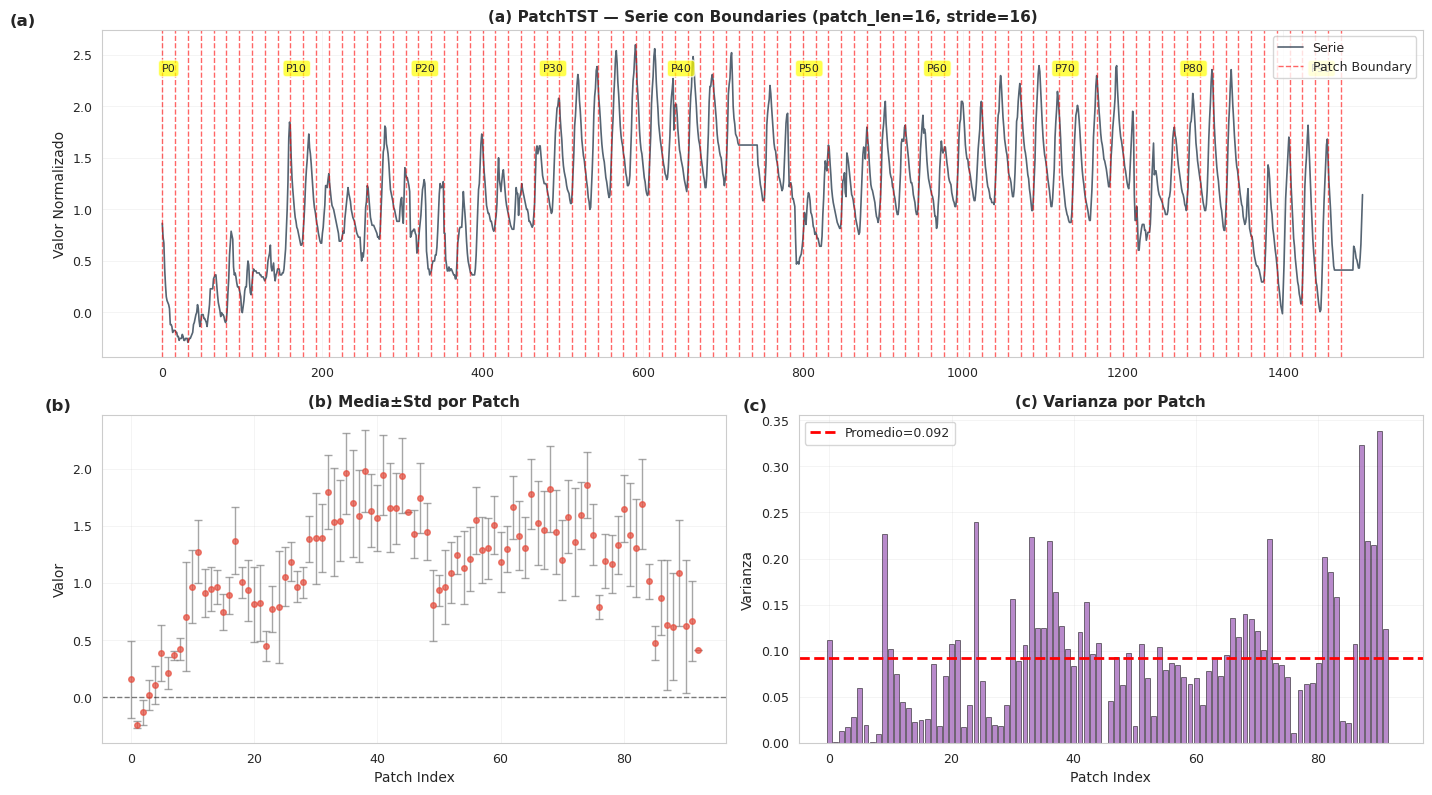

[ESTADÍSTICAS PATCHTST]
  Patch Length: 16 timesteps
  Stride: 16 (sin solapamiento)
  Num Patches: 93
  Compression Ratio: 16.13
  Timesteps cubiertos: 1488
  Timesteps descartados: 12

  Estadísticas de patches:
    Varianza media: 0.0919
    Std de varianzas: 0.0688
    Patch más variable: índice 90 (var=0.3386)
    Patch menos variable: índice 45 (var=0.0000)


In [13]:
patch_viz = visualize_patches(etth2_series, etth2_patch_array, 16, 16)

fig = plt.figure(figsize=(FIGSIZE_DOUBLE[0]*2, FIGSIZE_DOUBLE[1]*1.5))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])

ax1 = fig.add_subplot(gs[0, :])  # Panel (a) arriba, ancho completo
ax2 = fig.add_subplot(gs[1, 0])  # Panel (b) abajo izquierda
ax3 = fig.add_subplot(gs[1, 1])  # Panel (c) abajo derecha

# Panel (a): Serie con boundaries (sin overlap de etiquetas)
ax1.plot(etth2_series, linewidth=1.2, color='#2C3E50', alpha=0.8, label='Serie')
label_added = False
for i, pos in enumerate(patch_viz['positions']):
    ax1.axvline(pos, color='red', linestyle='--', linewidth=1, alpha=0.6,
                label='Patch Boundary' if not label_added else '')
    label_added = True
    # Etiquetar solo cada 10 patches para evitar overlap
    if i % 10 == 0 and i < len(patch_viz['positions']) - 1:
        mid_pos = pos + 8
        ax1.text(mid_pos, etth2_series.max()*0.9, f'P{i}', ha='center', fontsize=8,
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

ax1.set_title(f'(a) PatchTST — Serie con Boundaries (patch_len=16, stride=16)',
              fontsize=11, fontweight='bold')
ax1.set_ylabel('Valor Normalizado', fontsize=10)
ax1.legend(fontsize=9, loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.text(-0.05, 1.05, '(a)', transform=ax1.transAxes,
         fontsize=12, fontweight='bold', va='top', ha='right')

# Panel (b): Media±Std por patch
patch_means = etth2_patch_array.mean(axis=1)
patch_stds = etth2_patch_array.std(axis=1)
ax2.errorbar(range(len(patch_means)), patch_means, yerr=patch_stds,
             fmt='o', color='#E74C3C', ecolor='gray', alpha=0.7, capsize=3, markersize=4)
ax2.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_title('(b) Media±Std por Patch', fontsize=11, fontweight='bold')
ax2.set_xlabel('Patch Index', fontsize=10)
ax2.set_ylabel('Valor', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.text(-0.05, 1.05, '(b)', transform=ax2.transAxes,
         fontsize=12, fontweight='bold', va='top', ha='right')

# Panel (c): Varianza por patch
patch_vars = etth2_patch_array.var(axis=1)
ax3.bar(range(len(patch_vars)), patch_vars, color='#9B59B6', alpha=0.7, edgecolor='black', linewidth=0.5)
ax3.axhline(patch_vars.mean(), color='red', linestyle='--', linewidth=2,
           label=f'Promedio={patch_vars.mean():.3f}')
ax3.set_xlabel('Patch Index', fontsize=10)
ax3.set_ylabel('Varianza', fontsize=10)
ax3.set_title('(c) Varianza por Patch', fontsize=11, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, axis='y')
ax3.text(-0.05, 1.05, '(c)', transform=ax3.transAxes,
         fontsize=12, fontweight='bold', va='top', ha='right')

plt.tight_layout()

# Guardar figura
fig.savefig('figures/patchtst_patches_ETTh2.png', dpi=300, bbox_inches='tight')
plt.show()

print("[ESTADÍSTICAS PATCHTST]")
print(f"  Patch Length: 16 timesteps")
print(f"  Stride: 16 (sin solapamiento)")
print(f"  Num Patches: {patch_viz['num_patches']}")
print(f"  Compression Ratio: {patch_viz['compression_ratio']:.2f}")
print(f"  Timesteps cubiertos: {patch_viz['num_patches'] * 16}")
print(f"  Timesteps descartados: {len(etth2_series) - patch_viz['num_patches'] * 16}")
print(f"\n  Estadísticas de patches:")
print(f"    Varianza media: {patch_vars.mean():.4f}")
print(f"    Std de varianzas: {patch_vars.std():.4f}")
print(f"    Patch más variable: índice {patch_vars.argmax()} (var={patch_vars.max():.4f})")
print(f"    Patch menos variable: índice {patch_vars.argmin()} (var={patch_vars.min():.4f})")

## Técnica 5: Autoformer - Trend-Seasonal Decomposition

**Descripción:**
- Usa promedio móvil (kernel=25) para extraer tendencia
- Seasonal = Serie original - Trend
- Genera 2 tokens: (trend, seasonal)
- Cada componente se modela independientemente

**Interpretación:**
- Trend: componente de baja frecuencia (suave)
- Seasonal: componente de alta frecuencia (oscilaciones)
- Reconstrucción = Trend + Seasonal debe ≈ Serie original

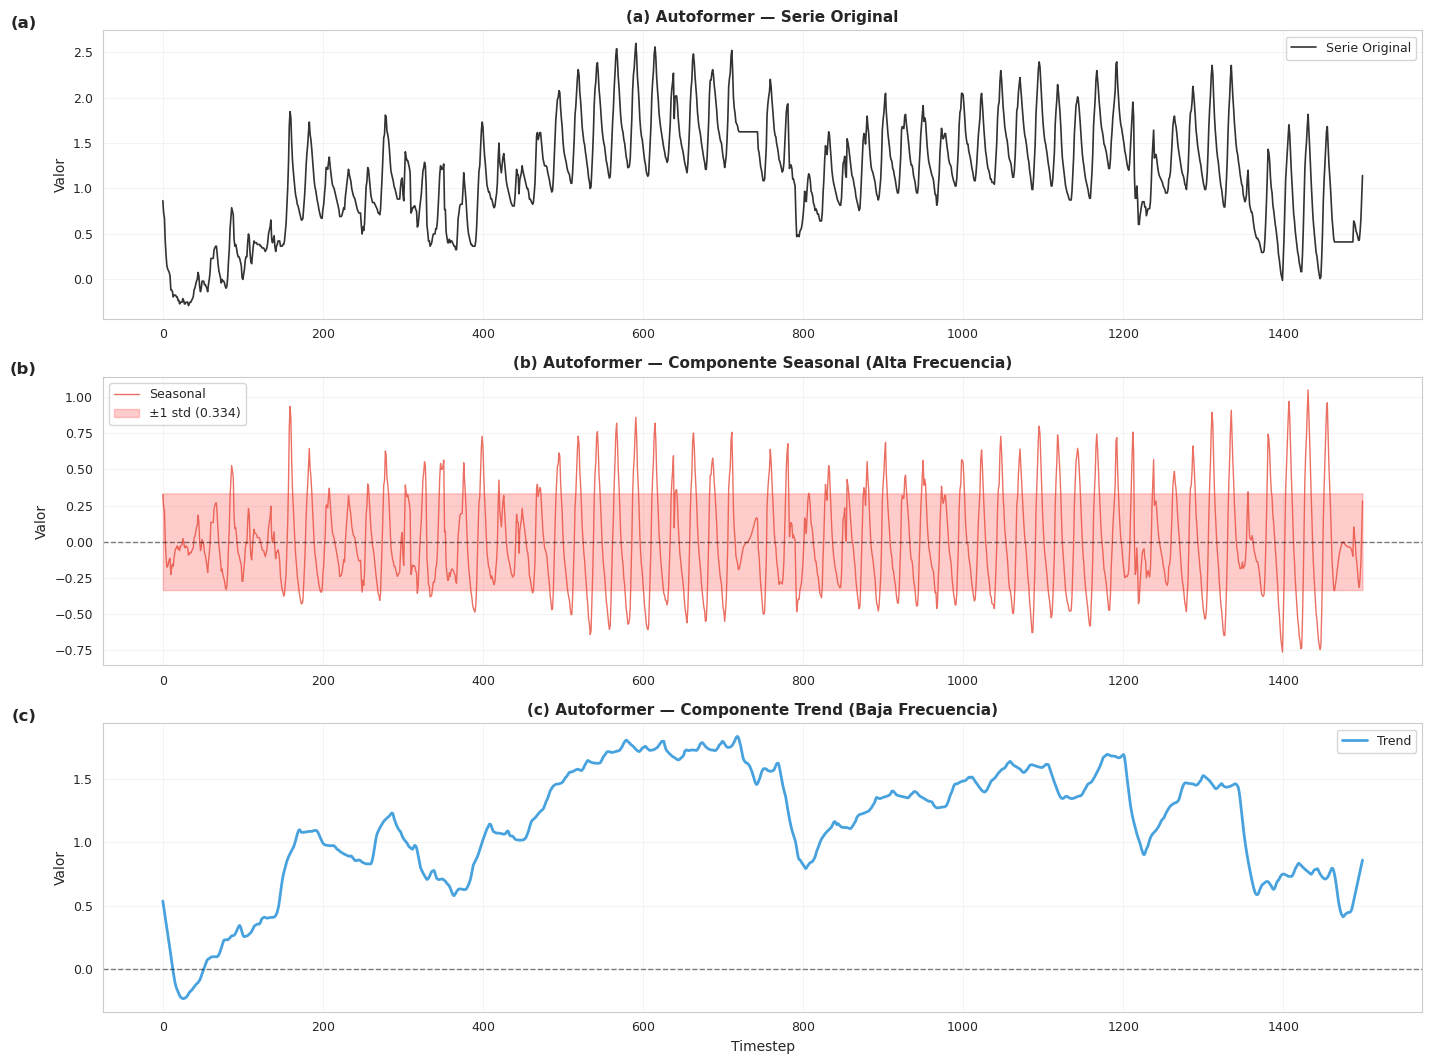

[ESTADÍSTICAS AUTOFORMER]
  Num Tokens: 2 (trend + seasonal)
  Compression Ratio: 750.00
  Kernel Size (promedio móvil): 25 timesteps

  Componente Seasonal:
    Media: -0.001889 (debe ser ~0)
    Std: 0.3339
    Rango: [-0.762, 1.048]

  Componente Trend:
    Media: 1.144698
    Std: 0.4745
    Rango: [-0.237, 1.839]

  Calidad Reconstrucción:
    MSE: 0.00000000
    MAE: 0.00000000
    Max Error Absoluto: 0.00000000


In [14]:
decomp_viz = visualize_decomposition(etth2_decomp)

fig, axes = plt.subplots(3, 1, figsize=(FIGSIZE_DOUBLE[0]*2, FIGSIZE_DOUBLE[1]*2))

# Panel (a): Serie original
axes[0].plot(etth2_series, linewidth=1.2, color='black', alpha=0.8, label='Serie Original')
axes[0].set_title('(a) Autoformer — Serie Original', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Valor', fontsize=10)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].text(-0.05, 1.05, '(a)', transform=axes[0].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='right')

# Panel (b): Componente Seasonal (alta frecuencia)
axes[1].plot(etth2_decomp['seasonal'], linewidth=1, color='#E74C3C', alpha=0.8, label='Seasonal')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
seasonal_std = etth2_decomp['seasonal'].std()
axes[1].fill_between(range(len(etth2_decomp['seasonal'])), -seasonal_std, seasonal_std,
                     alpha=0.2, color='red', label=f'±1 std ({seasonal_std:.3f})')
axes[1].set_title('(b) Autoformer — Componente Seasonal (Alta Frecuencia)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Valor', fontsize=10)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].text(-0.05, 1.05, '(b)', transform=axes[1].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='right')

# Panel (c): Componente Trend (baja frecuencia)
axes[2].plot(etth2_decomp['trend'], linewidth=2, color='#3498DB', alpha=0.9, label='Trend')
axes[2].axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[2].set_title('(c) Autoformer — Componente Trend (Baja Frecuencia)', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Timestep', fontsize=10)
axes[2].set_ylabel('Valor', fontsize=10)
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)
axes[2].text(-0.05, 1.05, '(c)', transform=axes[2].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='right')

plt.tight_layout()

# Guardar figura
fig.savefig('figures/autoformer_decomposition_ETTh2.png', dpi=300, bbox_inches='tight')
plt.show()

# Calcular métricas de reconstrucción para stats
error = np.abs(etth2_series - decomp_viz['reconstruction'])
mse = (error ** 2).mean()
mae = error.mean()

print("[ESTADÍSTICAS AUTOFORMER]")
print(f"  Num Tokens: {etth2_decomp['num_tokens']} (trend + seasonal)")
print(f"  Compression Ratio: {etth2_decomp['compression_ratio']:.2f}")
print(f"  Kernel Size (promedio móvil): 25 timesteps")
print(f"\n  Componente Seasonal:")
print(f"    Media: {etth2_decomp['seasonal'].mean():.6f} (debe ser ~0)")
print(f"    Std: {etth2_decomp['seasonal'].std():.4f}")
print(f"    Rango: [{etth2_decomp['seasonal'].min():.3f}, {etth2_decomp['seasonal'].max():.3f}]")
print(f"\n  Componente Trend:")
print(f"    Media: {etth2_decomp['trend'].mean():.6f}")
print(f"    Std: {etth2_decomp['trend'].std():.4f}")
print(f"    Rango: [{etth2_decomp['trend'].min():.3f}, {etth2_decomp['trend'].max():.3f}]")
print(f"\n  Calidad Reconstrucción:")
print(f"    MSE: {mse:.8f}")
print(f"    MAE: {mae:.8f}")
print(f"    Max Error Absoluto: {error.max():.8f}")

## Técnica 6: MOMENT - Masked Patch Pre-training

**Descripción:**
- Segmenta en patches como PatchTST
- Enmascara 30% de patches aleatoriamente
- Modelo aprende a reconstruir patches enmascarados
- Pre-training self-supervised para foundation model

**Interpretación:**
- Regiones rojas: patches enmascarados (ocultos al modelo)
- Regiones azules: patches visibles (observados)
- Modelo debe predecir valores en regiones enmascaradas

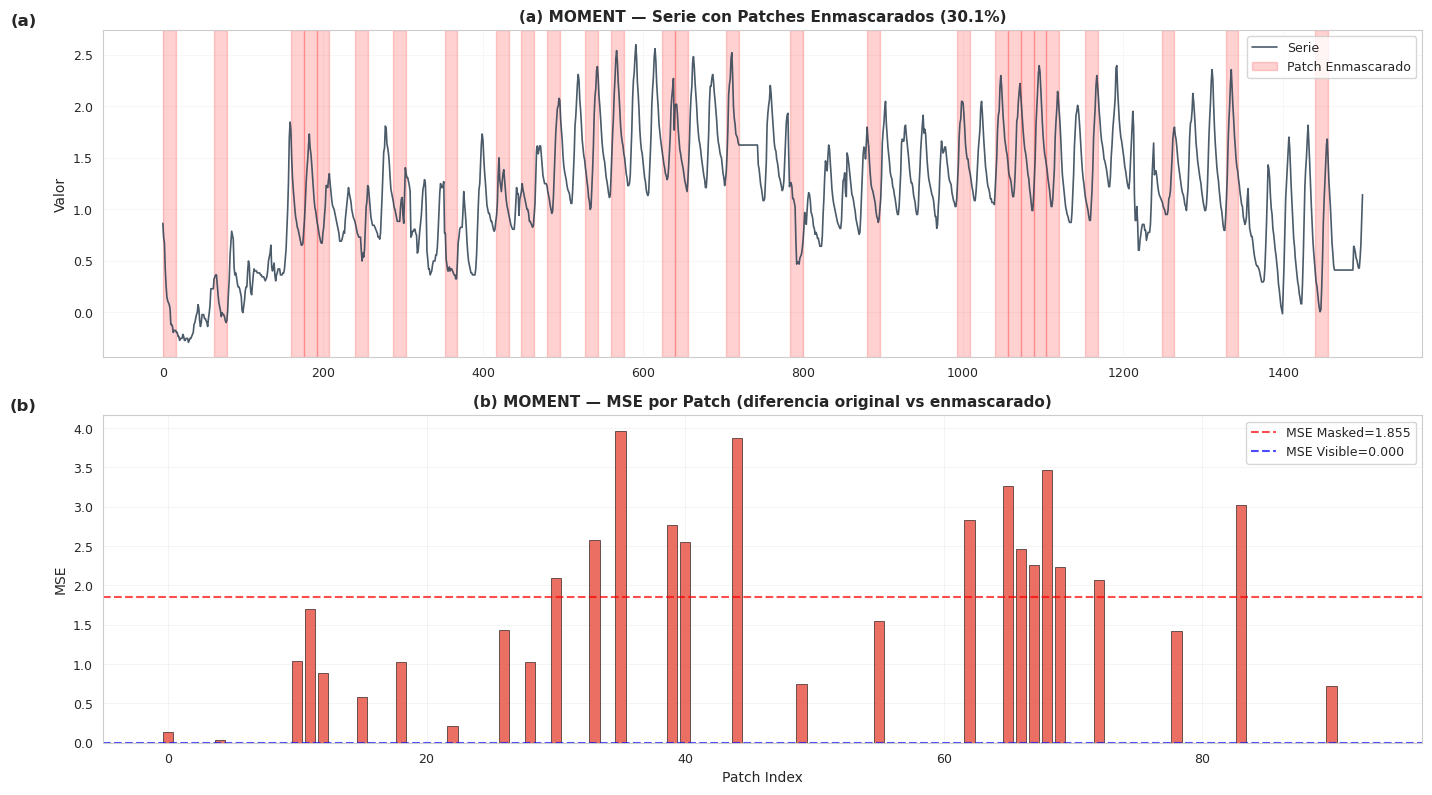

[ESTADÍSTICAS MOMENT]
  Patch Length: 16 timesteps
  Num Patches: 93
  Num Masked: 28 (índices: [0, 4, 10, 11, 12, 15, 18, 22, 26, 28, 30, 33, 35, 39, 40, 44, 49, 55, 62, 65, 66, 67, 68, 69, 72, 78, 83, 90])
  Mask Ratio: 30.1%
  Compression Ratio: 16.13

  MSE por tipo de patch:
    Masked (rojos): 1.8552
    Visible (azules): 0.0000
    Ratio Masked/Visible: infx


In [15]:
found_viz = visualize_foundation(etth2_series, etth2_foundation['patches'],
                                  etth2_foundation['mask'], 16, 16)

# Calcular MSE por patch (diferencia entre original y masked)
patches = etth2_foundation['patches']
masked = etth2_foundation['mask']
masked_patches = found_viz['masked_patches']
patch_errors = np.mean((patches - masked_patches)**2, axis=1)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(FIGSIZE_DOUBLE[0]*2, FIGSIZE_DOUBLE[1]*1.5))

# Panel (a): Serie con regiones enmascaradas
ax1.plot(etth2_series, linewidth=1.2, color='#2C3E50', alpha=0.85, label='Serie')
label_added = False
for i, (pos, is_mask) in enumerate(zip(found_viz['patch_positions'], masked)):
    if is_mask:
        ax1.axvspan(pos, pos+16, color='red', alpha=0.18, label='Patch Enmascarado' if not label_added else '')
        label_added = True

ax1.set_title(f'(a) MOMENT — Serie con Patches Enmascarados ({etth2_foundation["mask_ratio_actual"]*100:.1f}%)',
             fontsize=11, fontweight='bold')
ax1.set_ylabel('Valor', fontsize=10)
ax1.legend(fontsize=9, loc='upper right')
ax1.grid(True, alpha=0.2)
ax1.text(-0.05, 1.05, '(a)', transform=ax1.transAxes,
        fontsize=12, fontweight='bold', va='top', ha='right')

# Panel (b): MSE por patch (rojos=enmascarados, azules=visibles)
colors = ['#E74C3C' if m else '#3498DB' for m in masked]
ax2.bar(range(len(patch_errors)), patch_errors, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)

# Calcular MSE promedio para masked vs visible
mse_masked = patch_errors[masked].mean() if masked.any() else 0
mse_visible = patch_errors[~masked].mean() if (~masked).any() else 0

ax2.axhline(mse_masked, color='red', linestyle='--', linewidth=1.5, alpha=0.7,
           label=f'MSE Masked={mse_masked:.3f}')
ax2.axhline(mse_visible, color='blue', linestyle='--', linewidth=1.5, alpha=0.7,
           label=f'MSE Visible={mse_visible:.3f}')

ax2.set_title('(b) MOMENT — MSE por Patch (diferencia original vs enmascarado)',
             fontsize=11, fontweight='bold')
ax2.set_xlabel('Patch Index', fontsize=10)
ax2.set_ylabel('MSE', fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')
ax2.text(-0.05, 1.05, '(b)', transform=ax2.transAxes,
        fontsize=12, fontweight='bold', va='top', ha='right')

plt.tight_layout()

# Guardar figura
fig.savefig('figures/moment_masking_ETTh2.png', dpi=300, bbox_inches='tight')
plt.show()

print('[ESTADÍSTICAS MOMENT]')
print(f'  Patch Length: 16 timesteps')
print(f'  Num Patches: {etth2_foundation["num_patches"]}')
print(f'  Num Masked: {etth2_foundation["num_masked"]} (índices: {np.where(masked)[0].tolist()})')
print(f'  Mask Ratio: {etth2_foundation["mask_ratio_actual"]*100:.1f}%')
print(f'  Compression Ratio: {etth2_foundation["compression_ratio"]:.2f}')
print(f'\n  MSE por tipo de patch:')
print(f'    Masked (rojos): {mse_masked:.4f}')
print(f'    Visible (azules): {mse_visible:.4f}')
print(f'    Ratio Masked/Visible: {mse_masked/mse_visible if mse_visible > 0 else np.inf:.2f}x')

In [16]:
print("\n" + "-"*140)
print("RESUMEN FINAL - COMPARACIÓN DE TÉCNICAS DE TOKENIZACIÓN - ETTH2")
print("-"*140)
print(table_etth2.to_string(index=False))
print("-"*140)

print("\n[OBSERVACIONES CLAVE]")
print("  1. HMM: Vocabulary Size K=5 estados, genera segmentos mediante cambios de régimen")
print("  2. SAX: Vocabulary Size 8 símbolos, sin compresión (1:1), discretización interpretable")
print("  3. LLMTime: Vocabulary Size 13 caracteres, expansión de datos (CR < 1), permite uso de LLMs")
print("  4. PatchTST: Vocabulary continuo, compresión moderada (~16), reduce complejidad cuadrática")
print("  5. Autoformer: Vocabulary 2 componentes, máxima compresión (750)")
print("  6. MOMENT: Similar a PatchTST, enfoque en pre-training con masking")

print("\n[INTERPRETACIÓN HMM]")
print("  - Vocabulary Size = K = 5 estados ocultos (regímenes)")
print("  - Segmentos = cambios de estado detectados por Viterbi (run-length encoding)")
print("  - Compression Ratio = T / num_segmentos (mayor CR = mejor compresión)")
print("  - A MAYOR CR, MEJOR compresión (menos tokens necesarios)")

print("\n[OK] Comparación completada exitosamente")


--------------------------------------------------------------------------------------------------------------------------------------------
RESUMEN FINAL - COMPARACIÓN DE TÉCNICAS DE TOKENIZACIÓN - ETTH2
--------------------------------------------------------------------------------------------------------------------------------------------
      Técnica  Segmentos  Compression Ratio Vocabulary Size           Tipo                 Paper Dataset  Serie Length
HMM (Viterbi)         66          22.727273               5 Probabilístico    Tesis RITMO (2025)   ETTh2          1500
          SAX       1500           1.000000               8       Discreto     Lin et al. (2007)   ETTh2          1500
      LLMTime      15055           0.099635              13        Textual  Gruver et al. (2023)   ETTh2          1500
     PatchTST         93          16.129032        Continuo   Segmentación     Nie et al. (2023)   ETTh2          1500
   Autoformer          2         750.000000   2 componente

In [17]:
# Las figuras ya se guardaron automáticamente en cada celda
# Carpeta: figures/
from pathlib import Path
import os

fig_dir = Path('figures')
if fig_dir.exists():
    files = list(fig_dir.glob('*_ETTh2.png'))
    if files:
        print(f"[OK] {len(files)} figuras de ETTh2 guardadas en {fig_dir.absolute()}")
        for f in sorted(files):
            print(f"  ✓ {f.name}")
    else:
        print(f"[INFO] Ejecuta las celdas de visualización para generar las figuras")
else:
    print(f"[INFO] La carpeta {fig_dir} se creará al ejecutar las celdas de visualización")

[OK] 6 figuras de ETTh2 guardadas en /home/jaime/TFG/RITMO/tecnicas/figures
  ✓ autoformer_decomposition_ETTh2.png
  ✓ hmm_tokenizacion_ETTh2.png
  ✓ llmtime_text_based_ETTh2.png
  ✓ moment_masking_ETTh2.png
  ✓ patchtst_patches_ETTh2.png
  ✓ sax_discretizacion_ETTh2.png
